/var/folders/99/7h3twf753hz3syw9l72706vh0000gn/T/ipykernel_22461/1288382611.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Step_Count_Avg"].fillna(df["Step_Count_Avg"].mean(), inplace=True)
/var/folders/99/7h3twf753hz3syw9l72706vh0000gn/T/ipykernel_22461/1288382611.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we

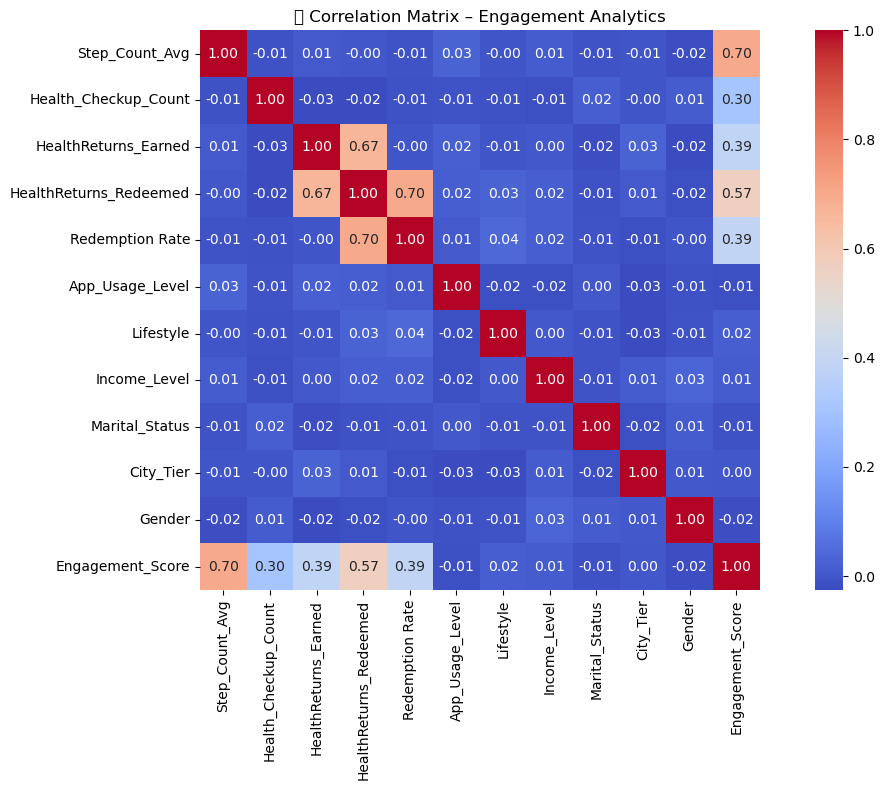

/var/folders/99/7h3twf753hz3syw9l72706vh0000gn/T/ipykernel_22461/1288382611.py:58: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


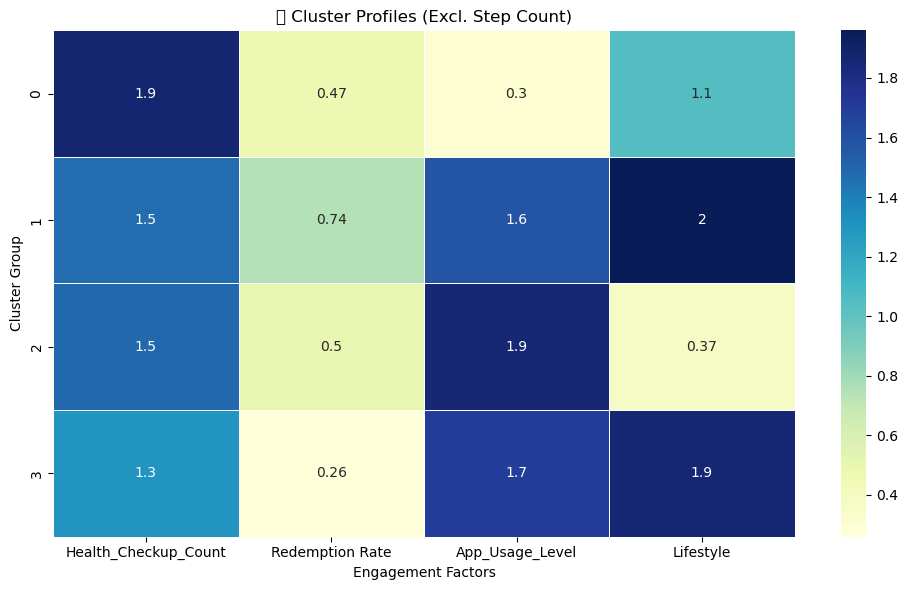

/var/folders/99/7h3twf753hz3syw9l72706vh0000gn/T/ipykernel_22461/1288382611.py:74: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


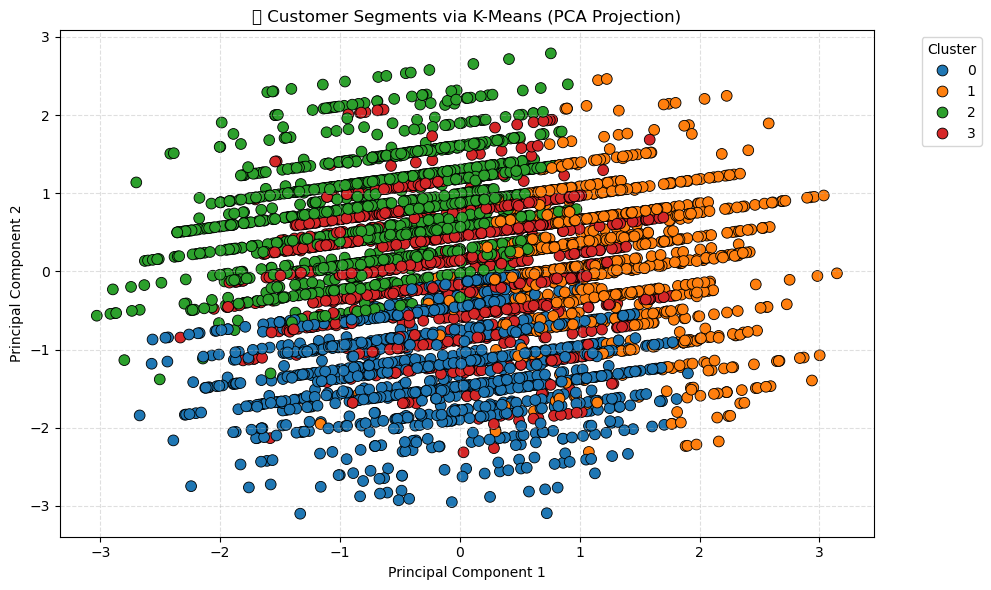

🌲 Random Forest Results:
Confusion Matrix:
 [[987  76]
 [ 94 343]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92      1063
           1       0.82      0.78      0.80       437

    accuracy                           0.89      1500
   macro avg       0.87      0.86      0.86      1500
weighted avg       0.89      0.89      0.89      1500

ROC-AUC Score: 0.9479281253565425


/var/folders/99/7h3twf753hz3syw9l72706vh0000gn/T/ipykernel_22461/1288382611.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_imp_df, palette="viridis")
/var/folders/99/7h3twf753hz3syw9l72706vh0000gn/T/ipykernel_22461/1288382611.py:108: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


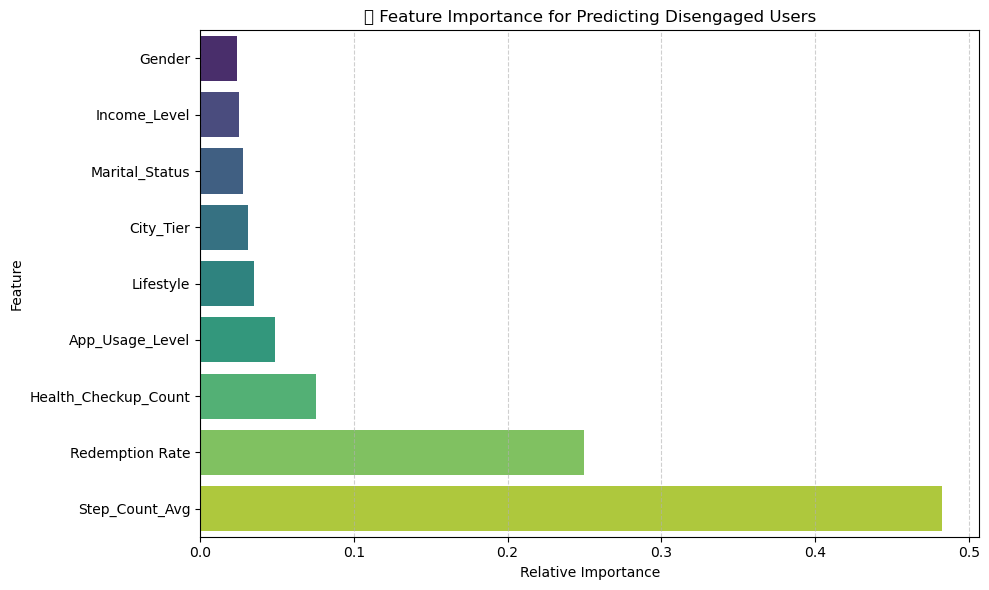

In [16]:
# -------------------- IMPORTS --------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# -------------------- LOAD & CLEAN DATA --------------------
df = pd.read_csv("Datasheet_Project_DS_660.csv")  # <== Use your actual path

# Encode categorical columns
label_cols = ["App_Usage_Level", "Lifestyle", "Income_Level", "Marital_Status", "City_Tier", "Gender", "Renewed"]
for col in label_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Fill nulls
df["Step_Count_Avg"].fillna(df["Step_Count_Avg"].mean(), inplace=True)
df["Health_Checkup_Count"].fillna(df["Health_Checkup_Count"].mean(), inplace=True)
df["Redemption Rate"].fillna(df["Redemption Rate"].mean(), inplace=True)

# -------------------- CORRELATION MATRIX --------------------
plt.figure(figsize=(12, 8))
corr = df[["Step_Count_Avg", "Health_Checkup_Count", "HealthReturns_Earned",
           "HealthReturns_Redeemed", "Redemption Rate", "App_Usage_Level",
           "Lifestyle", "Income_Level", "Marital_Status", "City_Tier",
           "Gender", "Engagement_Score"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("🔗 Correlation Matrix – Engagement Analytics")
plt.tight_layout()
plt.show()

# -------------------- CLUSTERING ANALYSIS (EXCLUDING STEP COUNT) --------------------
cluster_vars = ["Health_Checkup_Count", "Redemption Rate", "App_Usage_Level", "Lifestyle"]
df_cluster = df[cluster_vars].copy()

# Standardize data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df["Cluster_Group"] = kmeans.fit_predict(df_scaled)

# Cluster profiling
cluster_profile = df.groupby("Cluster_Group")[cluster_vars].mean().round(2)

# Heatmap for profiling
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile, annot=True, cmap="YlGnBu", linewidths=0.5)
plt.title("📊 Cluster Profiles (Excl. Step Count)")
plt.xlabel("Engagement Factors")
plt.ylabel("Cluster Group")
plt.tight_layout()
plt.show()

# PCA visualization for clusters
pca = PCA(n_components=2)
components = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(data=components, columns=["PC1", "PC2"])
df_pca["Cluster"] = df["Cluster_Group"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Cluster", palette="tab10", s=60, edgecolor='black')
plt.title("🔍 Customer Segments via K-Means (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# -------------------- PREDICTIVE MODELING --------------------
df["Disengaged"] = (df["Engagement_Score"] < 40).astype(int)
features = ["Step_Count_Avg", "Health_Checkup_Count", "Redemption Rate",
            "App_Usage_Level", "Lifestyle", "Income_Level", "Marital_Status",
            "City_Tier", "Gender"]
X = df[features]
y = df["Disengaged"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Evaluation
print("🌲 Random Forest Results:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

# -------------------- FEATURE IMPORTANCE --------------------
importances = rf.feature_importances_
feat_imp_df = pd.DataFrame({"Feature": X.columns, "Importance": importances})
feat_imp_df.sort_values(by="Importance", ascending=True, inplace=True)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feat_imp_df, palette="viridis")
plt.title("🔍 Feature Importance for Predicting Disengaged Users")
plt.xlabel("Relative Importance")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
